# P1 · Autograd follows the computation

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.14 · Autograd follows the computation

Backward accumulates gradients for learned leaf tensors. Updating their values is a separate operation.

**Prerequisites:** Predictions, targets, and loss

**Predict:** Does backward update learned parameter values?

**Mental model:** A loss value measures the current prediction, but an optimizer also needs to know how parameter changes affect that loss locally. Gradients provide that information.

### Why this operation exists

A loss value measures the current prediction, but an optimizer also needs to know how parameter changes affect that loss locally. Gradients provide that information.

Autograd records differentiable operations while the forward calculation runs. The resulting graph describes dependencies between values.

Backward combines local derivatives along those dependencies and accumulates contributions at learned leaf parameters.

A gradient is a rate of change, not a new parameter value. The optimizer later chooses how to turn that information into an update.

Use one parameter and a small squared error first. This isolates the programming behavior before the same mechanism runs through an entire transformer.

### Follow the values

Start with a learned scalar weight of two and no stored gradient. The fixed input in the first experiment is three.

Multiplying the weight by the input predicts six. This intermediate depends on the weight, so autograd records that dependency.

The target is one. Squaring the difference gives a loss of twenty-five.

Backward accumulates a gradient of thirty at the weight. In this calculation the derivative is twice the prediction error times the input.

The weight is still two after backward. Changing the input to four changes the prediction, loss and gradient, while backward still leaves the parameter value unchanged.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
w = torch.tensor(2., requires_grad=True)
x = torch.tensor(4. if change else 3.)
show("Leaf parameter before forward", {"w": w.item(), "grad": w.grad})
prediction = w*x
show("Prediction", prediction)
loss = (prediction-1).square()
show("Squared-error loss", loss)
loss.backward()
show("Gradient accumulated at w", w.grad)
show("Parameter after backward", w)

Leaf parameter before forward: {"w": 2.0, "grad": null}
Prediction: 6.0
  shape [] · torch.float32 · cpu
Squared-error loss: 25.0
  shape [] · torch.float32 · cpu
Gradient accumulated at w: 30.0
  shape [] · torch.float32 · cpu
Parameter after backward: 2.0
  shape [] · torch.float32 · cpu


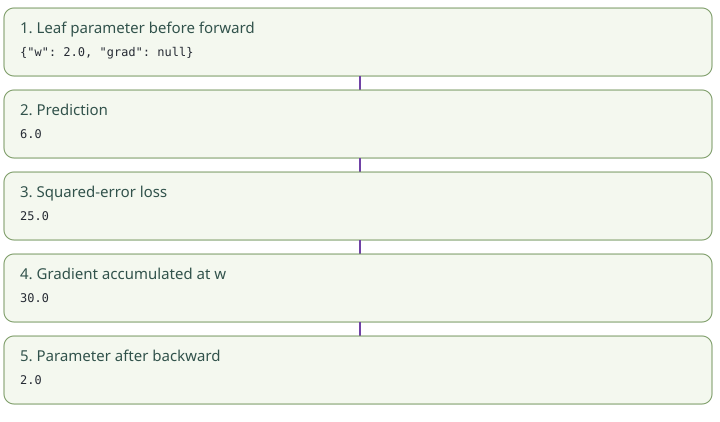

In [4]:
draw_trace()

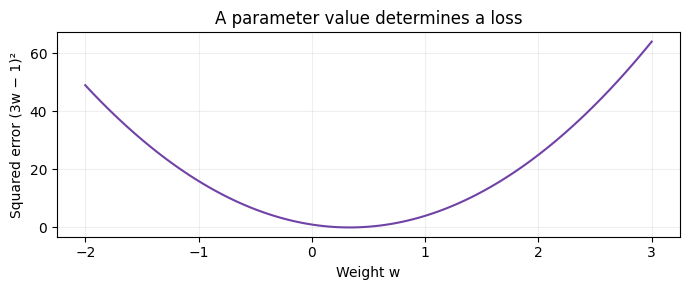

In [5]:
grid = torch.linspace(-2,3,120)
plt.figure(figsize=(7,3)); plt.plot(grid,(3*grid-1).square(),color="#7042a6")
plt.xlabel("Weight w"); plt.ylabel("Squared error (3w − 1)²"); plt.title("A parameter value determines a loss")
plt.grid(alpha=.2); plt.tight_layout(); plt.show()

### Read the implementation

Requires grad marks the leaf value whose gradient is needed. Operations using it create connected intermediate tensors while gradient recording is enabled.

The loss is scalar, so backward can begin from its implicit unit derivative. A non-scalar output requires an appropriate upstream gradient or a reduction.

Gradients normally accumulate in leaf tensors' grad fields. An intermediate's gradient is not automatically retained there for inspection.

Recomputing a forward graph and calling backward again adds another contribution unless gradients are cleared. The optimizer chapter will make clearing explicit.

Detach stops following a gradient connection but can share storage. Clone copies storage while remaining differentiable; detach followed by clone separates both concerns.

### Change one thing

**Increase the fixed input from 3 to 4**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [6]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
w = torch.tensor(2., requires_grad=True)
x = torch.tensor(4. if change else 3.)
show("Leaf parameter before forward", {"w": w.item(), "grad": w.grad})
prediction = w*x
show("Prediction", prediction)
loss = (prediction-1).square()
show("Squared-error loss", loss)
loss.backward()
show("Gradient accumulated at w", w.grad)
show("Parameter after backward", w)

Leaf parameter before forward: {"w": 2.0, "grad": null}
Prediction: 8.0
  shape [] · torch.float32 · cpu
Squared-error loss: 49.0
  shape [] · torch.float32 · cpu
Gradient accumulated at w: 56.0
  shape [] · torch.float32 · cpu
Parameter after backward: 2.0
  shape [] · torch.float32 · cpu


### A useful distinction

backward calculates and accumulates derivatives. It does not perform an optimizer update.

In [7]:
w = torch.tensor(2., requires_grad=True)
(w*3).backward(); first = w.grad.clone()
(w*3).backward(); torch.testing.assert_close(w.grad, first*2)
detached = w.detach(); copied = w.detach().clone()
assert not detached.requires_grad and not copied.requires_grad
assert detached.data_ptr() == w.data_ptr() and copied.data_ptr() != w.data_ptr()
print("Gradients accumulated; detach shared storage; detach plus clone copied it.")

Gradients accumulated; detach shared storage; detach plus clone copied it.


### ✋ Your turn

For w=2 with requires_grad=True, backpropagate through w.square() and put w.grad.item() in answer.

In [8]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 4, 'backward calculates and accumulates derivatives. It does not perform an optimizer update.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [9]:
#@title Show a solution { display-mode: "form" }
w = torch.tensor(2., requires_grad=True)
w.square().backward()
answer = w.grad.item()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 4, 'backward calculates and accumulates derivatives. It does not perform an optimizer update.'
    print("✓ right:", answer)

✓ right: 4.0


### Reconnect to the transformer

The model's scalar cross-entropy depends on projections, embeddings, normalization parameters and the readout. Autograd follows those actual tensor operations.

Shared token and readout weights receive contributions from both uses. There is one parameter with the sum of the relevant derivative contributions.

Integer input IDs name lookup entries; they are not continuous parameters to differentiate as magnitudes. The embedding weights receive gradients instead.

Converting a tensor to a Python value and rebuilding a new tensor can break the intended graph. Inspect grad function and requires grad when diagnosing a missing derivative.

Next, use the accumulated gradients in an optimizer step and verify exactly when values change.

```python
optimizer.zero_grad(set_to_none=True)
logits, loss = model(x, y)
loss.backward()
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Does backward update learned parameter values?

<details><summary>Check your explanation</summary>

No; it accumulates gradients. backward calculates and accumulates derivatives. It does not perform an optimizer update.

</details>